In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

OUTPUT_SUFFIXES = [
    "_output.musicxml",
    "_output.mxl",
    "_output.xml"
]

ALL_EXTENSIONS = [
    ".musicxml",
    ".mxl",
    ".xml",
]

def to_stem(filename: str) -> str:
    name = str(filename)
    for suf in OUTPUT_SUFFIXES:
        if name.lower().endswith(suf.lower()):
            return name[: -len(suf)]
    for ext in ALL_EXTENSIONS:
        if name.lower().endswith(ext.lower()):
            return name[: -len(ext)]
    return name
vns         = pd.read_csv('Parn_PDMX_VNS_Fixed.csv')
pianoplayer = pd.read_csv('Parn_PDMX_PP_Fixed.csv')
random      = pd.read_csv('Parn_PDMX_Random.csv')
dp = pd.read_csv('Parn_PDMX_DP.csv')

for df in [vns, pianoplayer, random, dp]:
    df['stem'] = df['file'].apply(to_stem)

# ── Keep only stems present in ALL models
shared_stems = (
    set(vns['stem'])
    & set(pianoplayer['stem'])
    & set(random['stem'])
    & set(dp['stem'])          # ← added
)
print(f"Shared pieces: {len(shared_stems)}")

vns         = vns        [vns        ['stem'].isin(shared_stems)]
pianoplayer = pianoplayer[pianoplayer['stem'].isin(shared_stems)]
random      = random     [random     ['stem'].isin(shared_stems)]
dp          = dp         [dp         ['stem'].isin(shared_stems)]

vns        ['model'] = 'VNS'
pianoplayer['model'] = 'PIANO PLAYER'
random     ['model'] = 'RANDOM'
dp         ['model'] = 'DP'

df = pd.concat([vns, pianoplayer, random, dp], axis=0, ignore_index=True)
df

Shared pieces: 261


,file,totalNotes,rule_1,rule_2,rule_3,rule_4,rule_5,rule_6,rule_7,rule_8,rule_9,rule_10,rule_11,rule_12,stem,model
0,Qma2wvbnmFgdbruyKfqLgndyFad3XyLbJN9n9f6Knb62nP...,134,3024,4156,1794,124,1149,84,86,27,1,0,4,0,Qma2wvbnmFgdbruyKfqLgndyFad3XyLbJN9n9f6Knb62nP,VNS
1,Qma3ZYuqhNFejkoqiPj4uNPGRpiRKEtQaJDMcL6zsHkMdc...,133,3460,5140,2217,119,1269,96,96,17,9,0,82,2,Qma3ZYuqhNFejkoqiPj4uNPGRpiRKEtQaJDMcL6zsHkMdc,VNS
2,Qma6sXcoaqDDYWthsxZFHacuGySGdvQcFRpjm9nMHsShhb...,76,1866,2636,1288,72,723,62,72,19,5,0,4,0,Qma6sXcoaqDDYWthsxZFHacuGySGdvQcFRpjm9nMHsShhb,VNS
3,Qma9Viq8gYVox8v45L2fShvsN3aXHtMAPFvmaJkd43WN2s...,168,4188,6259,2821,166,1516,129,130,23,7,5,64,4,Qma9Viq8gYVox8v45L2fShvsN3aXHtMAPFvmaJkd43WN2s,VNS
4,QmacV8wFedPppypix8TKE56iSYeZxyYTqjVpivhsQpnDpi...,120,3184,4388,2006,109,1237,87,80,22,0,0,0,0,QmacV8wFedPppypix8TKE56iSYeZxyYTqjVpivhsQpnDpi,VNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,QmZJKgGLSgt4DnXZPWsSpSUUK1r7k4mp75UkiRmDFPL54u...,120,172,154,235,70,135,84,81,7,2,93,30,23,QmZJKgGLSgt4DnXZPWsSpSUUK1r7k4mp75UkiRmDFPL54u,DP
1040,QmZnrvK1BDr6VKdM3LTBPpiX88TcRo1HHrFPdcd4WebdeC...,655,56,104,60,43,65,96,78,38,14,0,24,35,QmZnrvK1BDr6VKdM3LTBPpiX88TcRo1HHrFPdcd4WebdeC,DP
1041,QmZQspiHht99oxQxfb9awioVQh1YjxQqtxHQZA6kdG9Et7...,153,352,284,538,95,241,98,100,5,0,36,20,30,QmZQspiHht99oxQxfb9awioVQh1YjxQqtxHQZA6kdG9Et7,DP
1042,QmZwayJBnyhThwn3LeYGqdRzkX89rXfxQDTjjGFPmWz9iH...,183,352,229,389,121,258,132,125,7,2,223,76,46,QmZwayJBnyhThwn3LeYGqdRzkX89rXfxQDTjjGFPmWz9iH,DP


In [4]:
rule_cols = [c for c in dp.columns if c.startswith('rule_')]
print(f"Rule columns found: {rule_cols}")

for frame in [dp, vns, pianoplayer, random]:
    frame['total'] = frame[rule_cols].sum(axis=1)

# Merge all on stem
merged = dp[['stem', 'total']].rename(columns={'total': 'dp_total'}) \
    .merge(vns[['stem', 'total']].rename(columns={'total': 'vns_total'}), on='stem') \
    .merge(pianoplayer[['stem', 'total']].rename(columns={'total': 'pp_total'}), on='stem') \
    .merge(random[['stem', 'total']].rename(columns={'total': 'random_total'}), on='stem')

merged['vns_lower']    = (merged['dp_total'] < merged['vns_total']).astype(int)
merged['pp_lower']     = (merged['dp_total'] < merged['pp_total']).astype(int)
merged['random_lower'] = (merged['dp_total'] < merged['random_total']).astype(int)
merged['models_lower_than_dp'] = merged[['vns_lower', 'pp_lower', 'random_lower']].sum(axis=1)

print("Pieces where DP scores lower than each model:")
print(f"  VNS:          {merged['vns_lower'].sum()} / {len(merged)}")
print(f"  Piano Player: {merged['pp_lower'].sum()} / {len(merged)}")
print(f"  Random:       {merged['random_lower'].sum()} / {len(merged)}")

summary = merged['models_lower_than_dp'].value_counts().sort_index()
summary.index.name = 'models_dp_is_lower_than'
summary.name = 'piece_count'
print(f"\nBreakdown by how many models DP scores lower than:")
print(summary)

print(f"\nPieces where DP is lower than all 3 others: {(merged['models_lower_than_dp'] == 3).sum()} / {len(merged)}")
not_lower = merged[merged['models_lower_than_dp'] < 3]
print(f"\nPieces where DP does NOT score lower than all 3 models ({len(not_lower)}):")
print(not_lower[['stem', 'dp_total', 'vns_total', 'pp_total', 'random_total', 'models_lower_than_dp']].to_string())



print("\nAverage scores:")
print(f"  DP:           {merged['dp_total'].mean():.1f}")
print(f"  VNS:          {merged['vns_total'].mean():.1f}")
print(f"  Piano Player: {merged['pp_total'].mean():.1f}")
print(f"  Random:       {merged['random_total'].mean():.1f}")

print("\nDP scored lower by (% difference from DP):")
print(f"  vs VNS:          {((merged['vns_total'] - merged['dp_total']) / merged['vns_total'] * 100).mean():.1f}%")
print(f"  vs Piano Player: {((merged['pp_total'] - merged['dp_total']) / merged['pp_total'] * 100).mean():.1f}%")
print(f"  vs Random:       {((merged['random_total'] - merged['dp_total']) / merged['random_total'] * 100).mean():.1f}%")

Rule columns found: ['rule_1', 'rule_2', 'rule_3', 'rule_4', 'rule_5', 'rule_6', 'rule_7', 'rule_8', 'rule_9', 'rule_10', 'rule_11', 'rule_12']
Pieces where DP scores lower than each model:
  VNS:          260 / 261
  Piano Player: 259 / 261
  Random:       260 / 261

Breakdown by how many models DP scores lower than:
models_dp_is_lower_than
0      1
2      1
3    259
Name: piece_count, dtype: int64

Pieces where DP is lower than all 3 others: 259 / 261

Pieces where DP does NOT score lower than all 3 models (2):
                                               stem  dp_total  vns_total  pp_total  random_total  models_lower_than_dp
18   QmbbNRWP3gr5ooxoEcNCNfyB7aBYw9k7CKBTD2Rvj4dp9k      5783      18091      4954         13873                     2
192  QmVdTMNyYdTqLsjGCHepLaoMBJ9h8FUJQxjsUUtHJjAgVU     10972       9704      1892          6433                     0

Average scores:
  DP:           1270.3
  VNS:          11381.8
  Piano Player: 2661.4
  Random:       7851.8

DP scored low

In [5]:
# Change column names
dp_notes = dp.set_index('stem')['totalNotes']
metric_names = {
    "file": "Piece",
    "totalNotes": "Total Notes",
    "rule_1": "Stretch",
    "rule_2": "Large Span",
    "rule_3": "Small Span",
    "rule_4": "Position Change Count",
    "rule_5": "Position Change Size",
    "rule_6": "Weak Finger",
    "rule_7": "3-4-5",
    "rule_8": "3-4",
    "rule_9": "4 on Black",
    "rule_10": "Thumb on Black",
    "rule_11": "5 on Black",
    "rule_12": "Thumb Passing"
}

df = df.rename(metric_names, axis = 1)

# Total Score
df["Total Score"] = df.iloc[:, 2:14].sum(axis = 1)

# Normalized Total Score (dividing by total notes)
df['Avg Score per Note'] = df['Total Score'] / df['Total Notes']

# Overwrite Total Notes for every row using DP's values
df['Total Notes'] = df['stem'].map(dp_notes)

# (optional) sanity check – should be 0
print("Missing note counts:", df['Total Notes'].isna().sum())

Missing note counts: 0


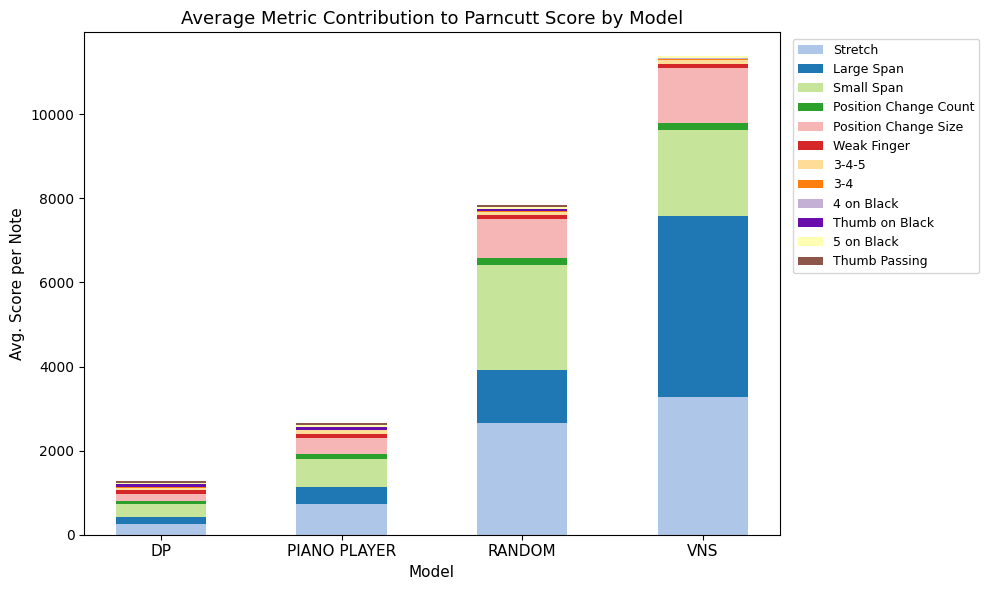

In [6]:
# Graph 1: Stacked Column Chart
# y-axis: Avg. Score per Note
# x-axis: model

metrics = ['Stretch', 'Large Span', 'Small Span', 'Position Change Count', 'Position Change Size', 'Weak Finger', '3-4-5', '3-4', '4 on Black', 'Thumb on Black', '5 on Black', 'Thumb Passing']

grouped = df.groupby('model')[metrics].mean()

colors = [
    '#aec6e8', '#1f77b4', '#c7e59a', '#2ca02c',
    '#f7b6b6', '#d62728', '#ffdd99', '#ff7f0e',
    '#c5b0d5', '#6a0dad', '#ffffb3', '#8c564b'
]

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(grouped))
x = np.arange(len(grouped))

for i, metric in enumerate(metrics):
    ax.bar(
        x,
        grouped[metric],
        bottom=bottom,
        label=metric,
        color=colors[i],
        width=0.5
    )
    bottom += grouped[metric].values

ax.set_xticks(x)
ax.set_xticklabels(grouped.index, fontsize=11)
ax.set_ylabel('Avg. Score per Note', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_title('Average Metric Contribution to Parncutt Score by Model', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()

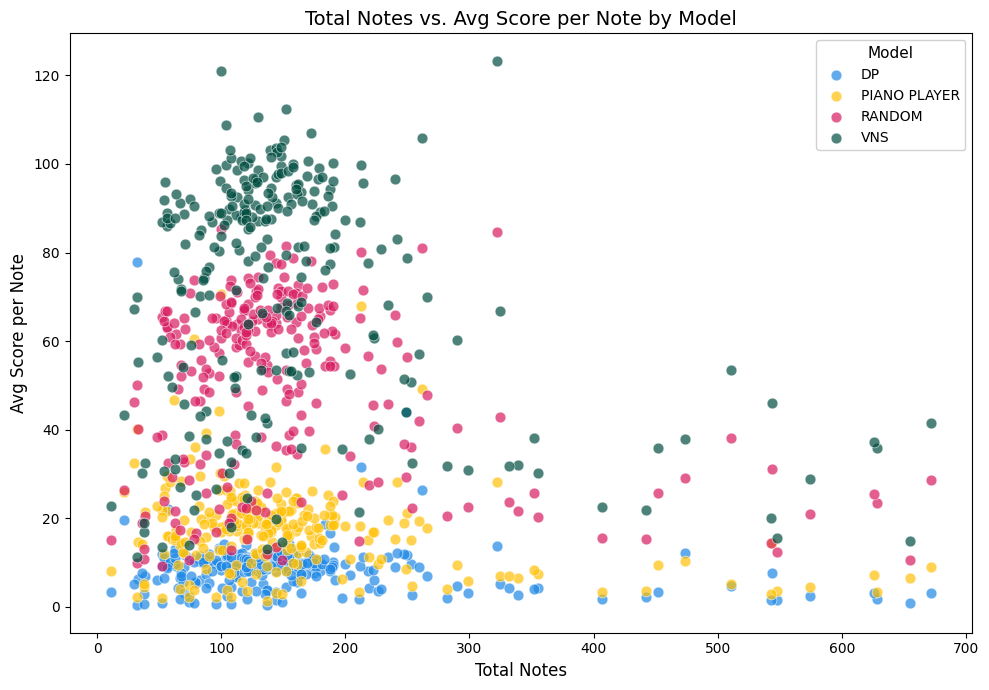

In [7]:
# Graph 2: Scatterplot
# x-axis: Total Score
# y-axis: Avg Score per Note

model_colors = {
    'RANDOM':      '#D81B60',   # red
    'VNS':         '#004D40',   # green
    'PIANO PLAYER': '#FFC107',   # yellow
    'DP':          '#1E88E5',   # blue (include if needed)
}


fig, ax = plt.subplots(figsize=(10, 7))

for model, group in df.groupby('model'):
    color = model_colors.get(model, '#888888')
    ax.scatter(
        group['Total Notes'],
        group['Avg Score per Note'],
        label=model,
        color=color,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5,
        s=60
    )

# --- Formatting ---
ax.set_xlabel('Total Notes', fontsize=12)
ax.set_ylabel('Avg Score per Note', fontsize=12)
ax.set_title('Total Notes vs. Avg Score per Note by Model', fontsize=14)
ax.legend(title='Model', fontsize=10, title_fontsize=11, framealpha=0.9)


plt.tight_layout()
plt.show()

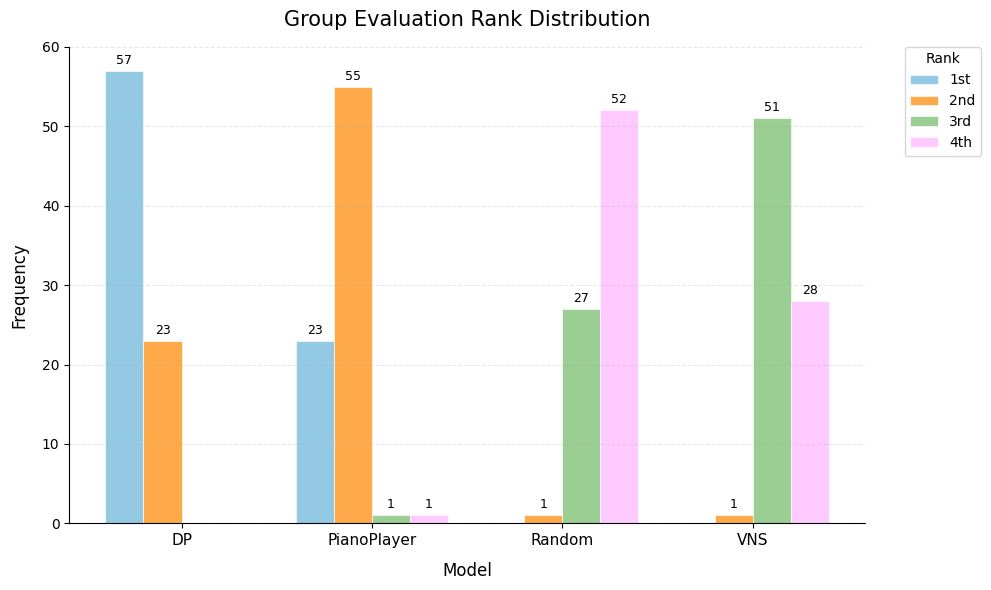

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['DP', 'PianoPlayer', 'Random', 'VNS']
ranks = ['1st', '2nd', '3rd', '4th']

# Rows = models, Columns = ranks (1st, 2nd, 3rd, 4th)
data = [
    [57, 23,  0,  0],   # DP
    [23, 55,  1,  1],   # PianoPlayer
    [ 0,  1, 27, 52],   # Random
    [ 0,  1, 51, 28],   # VNS

]

colors = ['#89C4E1', '#FFA136', '#90C987', '#FEC5FF']


x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, (rank, color) in enumerate(zip(ranks, colors)):
    counts = [data[m][i] for m in range(len(models))]
    bars = ax.bar(x + i * width, counts, width, label=rank, color=color, alpha=0.9, edgecolor='white', linewidth=0.5)
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    str(count), ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12, labelpad=10)
ax.set_ylabel('Frequency', fontsize=12, labelpad=10)
ax.set_title('Group Evaluation Rank Distribution', fontsize=15, pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, fontsize=11)
ax.legend(title='Rank', fontsize=10, title_fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.set_ylim(0, 60)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()